In [368]:
from brian2 import *
import time
import matplotlib.pyplot as plt

#Settings
start_scope()
DT = 0.01
defaultclock.dt = DT * ms
duration_in_min = 1/3
TotTime = int(duration_in_min*60000)
duration = TotTime * ms
N = 1000

print('Simulated minutes:', duration_in_min)
print('Simulated time steps(ms):', TotTime)
print('Neurons in the population:', N)

#Parameters
eta_bar= 0.
Delta=10.
E=0
J=10/N

Evar=np.append(np.zeros(int(N-N/4)),-80*np.ones(int(N/4)))

Kbath=3.5
z0=[-15.0, 0.45, -3.5, -12]

Vth= -50 # -60# buono -67.3# -19#
s=np.random.standard_cauchy(N)* Delta +eta_bar 
s=s[(s>-20+eta_bar)&(s<20+eta_bar)]
s=np.append(s,eta_bar*np.ones(N-len(s)))

Par = {'Cnap': 21.0,  # mol.m**-3 
       'DCnap': 2.0,  # mol.m**-3 
       'Ckp': 5.5,  # mol.m**-3 
       'DCkp': 1.0,  # mol.m**-3 
       'Cmna': -24.0,  # mV 
       'DCmna': 12.0,  # mV 
       'Chn': 0.4,  # dimensionless 
       'DChn': -8.0,  # dimensionless 
       'Cnk': -19.0,  # mV 
       'DCnk': 18.0,  # mV #Ok in the paper
       'g_Cl': 7.5,  # nS #Ok in the paper
       'g_Na': 40.0,  # nS 
       'g_K': 22.0,  # nS 
       'g_Nal': 0.02,  # nS 
       'g_Kl': 0.12,  # nS 
       'rho': 250.,  # 250.,#pamp 
       'w_i': 2160.0,  # umeter 
       'w_o': 720.0,  # umeter 
       'Na_i0': 16.0,  # mol.m**-3 
       'Na_o0': 138.0,  # mol.m**-3 
       'K_i0': 130.0,  # mol.m**-3 
       'K_o0': 4.80,  # mol.m**-3 
       'Cl_o0': 112.0,  # mol.m**-3 
       'Cl_i0': 5.0,  # mol.m**-3 
       ## Time costants
       'Cm': 1,
       'tau_n': 4,
       'gamma': 0.04,  
       'epsilon': 0.001,
       'tau_I': 1
      }

eqs = '''
DNa_i = -DK_i : 1 (constant over dt)
DNa_o = -beta * DNa_i : 1 (constant over dt)
DK_o = -beta * DK_i : 1 (constant over dt)
K_i = K_i0 + DK_i : 1 (constant over dt)
Na_i = Na_i0 + DNa_i : 1 (constant over dt)
Na_o = Na_o0 + DNa_o : 1 (constant over dt)
K_o = K_o0 + DK_o + Kg : 1 (constant over dt)

n_inf= 1.0/(1.0+exp((Cnk-V)/DCnk)): 1
m_inf= 1.0/(1.0+exp((Cmna-V)/DCmna)): 1
h_n= 1.1 - 1.0 / (1.0 + exp(DChn * (n - Chn))): 1

I_K   = (g_Kl+g_K*n)*(V- 26.64*log(K_o/K_i)) : 1 
I_Na  = (g_Nal+g_Na*m_inf*h_n)*(V- 26.64*log(Na_o/Na_i)) : 1 
I_Cl  = g_Cl*(V+ 26.64*log(Cl_o0/Cl_i0)) : 1 
I_pump= rho*(1.0/(1.0+exp((Cnap - Na_i) / DCnap))*(1.0/(1.0+exp((Ckp - K_o)/DCkp)))) : 1 

dV/dt = (-1.0/Cm)*(I_Na+I_K+I_Cl+I_pump)+(eta)/tau_I: 1
dn/dt = (n_inf - n) / tau_n : 1
dDK_i/dt = -(gamma/w_i) * (I_K-2*I_pump): 1
dKg/dt = epsilon * (K_bath - K_o) : 1

Cnap : 1
DCnap : 1
Ckp : 1
DCkp : 1
Cmna : 1
DCmna : 1
Chn : 1
DChn : 1
Cnk : 1
DCnk : 1
Cm : second
tau_n : second
tau_I : second
g_Cl : 1
g_Na : 1
g_K : 1
g_Nal : 1
g_Kl : 1
w_i : 1
w_o : 1
rho : 1
beta : 1
epsilon : hertz
gamma : hertz
K_bath : 1
Na_i0 : 1
Na_o0 : 1
K_i0 : 1
K_o0 : 1
Cl_o0 : 1
Cl_i0 : 1
E : 1
J: 1
eta:1

'''

Population={}
G1 = NeuronGroup(N, eqs, threshold='V > Vth', refractory='V > Vth', method='heun') #rk4
G1.V = (z0[0]+1*randn(N)) * 1
G1.n = (z0[1]+0.05*randn(N)) * 1
G1.DK_i = z0[2]+0.3*randn(N) *1 #DK_i0 * 1
G1.Kg = z0[3]+0.3*randn(N) *1 #Kg0 * 1
G1.Cnap = Par['Cnap'] * 1  
G1.DCnap = Par['DCnap'] * 1 
G1.Ckp = Par['Ckp'] * 1  
G1.DCkp = Par['DCkp'] * 1  
G1.Cmna = Par['Cmna'] * 1  
G1.DCmna = Par['DCmna'] * 1  
G1.Chn = Par['Chn'] * 1  
G1.DChn = Par['DChn'] * 1 
G1.Cnk = Par['Cnk'] * 1  
G1.DCnk = Par['DCnk'] * 1  
G1.Cm = Par['Cm'] * ms  
G1.tau_n = Par['tau_n'] * ms   
G1.g_Cl = Par['g_Cl'] * 1  
G1.g_Na = Par['g_Na'] * 1  
G1.g_K = Par['g_K'] * 1  ,
G1.g_Nal = Par['g_Nal'] * 1  
G1.g_Kl = Par['g_Kl'] * 1 
G1.rho = Par['rho'] * 1  
G1.w_i = Par['w_i'] * 1
G1.w_o = Par['w_o'] * 1
G1.beta = Par['w_i'] / Par['w_o'] * 1 
G1.tau_I = Par['tau_I'] * ms  
G1.epsilon = Par['epsilon'] * (1 / ms)  
G1.gamma = Par['gamma'] * (1 / ms)  
G1.Na_i0 = Par['Na_i0'] * 1  
G1.Na_o0 = Par['Na_o0'] * 1  
G1.K_i0 = Par['K_i0'] * 1  
G1.K_o0 = Par['K_o0'] * 1  
G1.Cl_o0 = Par['Cl_o0'] * 1  
G1.Cl_i0 = Par['Cl_i0'] * 1  
G1.E = (E +Evar) * 1   
G1.J = J * 1  
G1.eta =s
G1.K_bath = Kbath * 1
print('K_bath=%.2f'%G1.K_bath[0])
print('J=%.6f'%G1.J[0])

MG1 = StateMonitor(G1, ('V', 'n', 'DK_i', 'Kg', 'K_o'), record=True, dt= 1*ms)
MG1_spike = SpikeMonitor(G1)
FRG1 = PopulationRateMonitor(G1)
S_G1G1 = Synapses(G1, G1, on_pre='V+=J*(E-V) ', method='heun')
S_G1G1.connect('i!=j')
net = Network(G1,MG1, MG1_spike, S_G1G1)

print('--##Start simulation##--')
tic = time.time()
run(duration, report='stdout', report_period=30*second)
tac = time.time()
print('--##End simulation##--')
print('Time : {}s'.format(tac - tic))

Population[Kbath]={}
Population[Kbath]['x']=np.var(MG1.V,axis=0)
Population[Kbath]['V']=np.mean(MG1.V,axis=0)
Population[Kbath]['n']=np.mean(MG1.n,axis=0)
Population[Kbath]['r']=FRG1.rate/Hz
Population[Kbath]['DK_i']=np.mean(MG1.DK_i,axis=0)
Population[Kbath]['Kg']=np.mean(MG1.Kg,axis=0)

Simulated minutes: 0.3333333333333333
Simulated time steps(ms): 20000
Neurons in the population: 1000
K_bath=3.50
J=0.010000
--##Start simulation##--


WARNING    'E' is an internal variable of group 'synapses_1', but also exists in the run namespace with the value 0. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'J' is an internal variable of group 'synapses_1', but also exists in the run namespace with the value 0.01. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    Came across an abstract code block that may not be well-defined: the outcome may depend on the order of execution. You can ignore this warning if you are sure that the order of operations does not matter. Abstract code: 'V += J * (E - V) (in-place)'
 [brian2.codegen.generators.base]


Starting simulation at t=0. s for a duration of 20. s


KeyboardInterrupt: 

In [501]:
from brian2 import *
import time
import matplotlib.pyplot as plt

#Settings
start_scope()
DT = 0.01
defaultclock.dt = DT * ms
duration_in_min = 1/5
TotTime = int(duration_in_min*60000)
duration = TotTime * ms
N = 1000

print('Simulated minutes:', duration_in_min)
print('Simulated time steps(ms):', TotTime)
print('Neurons in the population:', N)

#Parameters
eta_bar= 0.
Delta=2.
E=0
J=20/N

Evar=0#np.append(np.zeros(int(N-N/4)),-80*np.ones(int(N/4)))

Kbath=15.5
z0=[-15.0, 0.45, -5, -16]

Vth= -40 # -60# buono -67.3# -19#
s=np.random.standard_cauchy(N)* Delta +eta_bar 
#s=s[(s>-20+eta_bar)&(s<20+eta_bar)]
#s=np.append(s,eta_bar*np.ones(N-len(s)))

Par = {'Cnap': 21.0,  # mol.m**-3 
       'DCnap': 2.0,  # mol.m**-3 
       'Ckp': 5.5,  # mol.m**-3 
       'DCkp': 1.0,  # mol.m**-3 
       'Cmna': -24.0,  # mV 
       'DCmna': 12.0,  # mV 
       'Chn': 0.4,  # dimensionless 
       'DChn': -8.0,  # dimensionless 
       'Cnk': -19.0,  # mV 
       'DCnk': 18.0,  # mV #Ok in the paper
       'g_Cl': 7.5,  # nS #Ok in the paper
       'g_Na': 40.0,  # nS 
       'g_K': 22.0,  # nS 
       'g_Nal': 0.02,  # nS 
       'g_Kl': 0.12,  # nS 
       'rho': 250.,  # 250.,#pamp 
       'w_i': 2160.0,  # umeter 
       'w_o': 720.0,  # umeter 
       'K_bath': 12.5,  # mol.m**-3
       'Na_i0': 16.0,  # mol.m**-3 
       'Na_o0': 138.0,  # mol.m**-3 
       'K_i0': 130.0,  # mol.m**-3 
       'K_o0': 4.80,  # mol.m**-3 
       'Cl_o0': 112.0,  # mol.m**-3 
       'Cl_i0': 5.0,  # mol.m**-3 
       'E': 0., #check
       
       ## Time costants
       'Cm': 1,#10, #1
       'tau_n': 4,#2.5,#4 
       'gamma': 0.04,  
       'epsilon': 0.001,
       'tau_I': 1
      }

eqs = '''
DNa_i = -DK_i : 1 (constant over dt)
DNa_o = -beta * DNa_i : 1 (constant over dt)
DK_o = -beta * DK_i : 1 (constant over dt)
K_i = K_i0 + DK_i : 1 (constant over dt)
Na_i = Na_i0 + DNa_i : 1 (constant over dt)
Na_o = Na_o0 + DNa_o : 1 (constant over dt)
K_o = K_o0 + DK_o + Kg : 1 (constant over dt)

n_inf= 1.0/(1.0+exp((Cnk-V)/DCnk)): 1
m_inf= 1.0/(1.0+exp((Cmna-V)/DCmna)): 1
h_n= 1.1 - 1.0 / (1.0 + exp(DChn * (n - Chn))): 1

I_K   = (g_Kl+g_K*n)*(V- 26.64*log(K_o/K_i)) : 1 
I_Na  = (g_Nal+g_Na*m_inf*h_n)*(V- 26.64*log(Na_o/Na_i)) : 1 
I_Cl  = g_Cl*(V+ 26.64*log(Cl_o0/Cl_i0)) : 1 
I_pump= rho*(1.0/(1.0+exp((Cnap - Na_i) / DCnap))*(1.0/(1.0+exp((Ckp - K_o)/DCkp)))) : 1 

dV/dt = (-1.0/Cm)*(I_Na+I_K+I_Cl+I_pump)+(eta)/tau_I: 1
dn/dt = (n_inf - n) / tau_n : 1
dDK_i/dt = -(gamma/w_i) * (I_K-2*I_pump): 1
dKg/dt = epsilon * (K_bath - K_o) : 1

Cnap : 1
DCnap : 1
Ckp : 1
DCkp : 1
Cmna : 1
DCmna : 1
Chn : 1
DChn : 1
Cnk : 1
DCnk : 1
Cm : second
tau_n : second
tau_I : second
g_Cl : 1
g_Na : 1
g_K : 1
g_Nal : 1
g_Kl : 1
w_i : 1
w_o : 1
rho : 1
beta : 1
epsilon : hertz
gamma : hertz
K_bath : 1
Na_i0 : 1
Na_o0 : 1
K_i0 : 1
K_o0 : 1
Cl_o0 : 1
Cl_i0 : 1
E : 1
J: 1
eta:1

'''

Population={}
G1 = NeuronGroup(N, eqs, threshold='V > Vth', refractory='V > Vth', method='heun') #rk4
G1.V = (z0[0]+1*randn(N)) * 1
G1.n = (z0[1]+0.05*randn(N)) * 1
G1.DK_i = z0[2]+0.3*randn(N) *1 #DK_i0 * 1
G1.Kg = z0[3]+0.3*randn(N) *1 #Kg0 * 1
G1.Cnap = Par['Cnap'] * 1  
G1.DCnap = Par['DCnap'] * 1 
G1.Ckp = Par['Ckp'] * 1  
G1.DCkp = Par['DCkp'] * 1  
G1.Cmna = Par['Cmna'] * 1  
G1.DCmna = Par['DCmna'] * 1  
G1.Chn = Par['Chn'] * 1  
G1.DChn = Par['DChn'] * 1 
G1.Cnk = Par['Cnk'] * 1  
G1.DCnk = Par['DCnk'] * 1  
G1.Cm = Par['Cm'] * ms  
G1.tau_n = Par['tau_n'] * ms   
G1.g_Cl = Par['g_Cl'] * 1  
G1.g_Na = Par['g_Na'] * 1  
G1.g_K = Par['g_K'] * 1  ,
G1.g_Nal = Par['g_Nal'] * 1  
G1.g_Kl = Par['g_Kl'] * 1 
G1.rho = Par['rho'] * 1  
G1.w_i = Par['w_i'] * 1
G1.w_o = Par['w_o'] * 1
G1.beta = Par['w_i'] / Par['w_o'] * 1 
G1.tau_I = Par['tau_I'] * ms  
G1.epsilon = Par['epsilon'] * (1 / ms)  
G1.gamma = Par['gamma'] * (1 / ms)  
G1.Na_i0 = Par['Na_i0'] * 1  
G1.Na_o0 = Par['Na_o0'] * 1  
G1.K_i0 = Par['K_i0'] * 1  
G1.K_o0 = Par['K_o0'] * 1  
G1.Cl_o0 = Par['Cl_o0'] * 1  
G1.Cl_i0 = Par['Cl_i0'] * 1  
G1.E = (E +Evar) * 1   
G1.J = J * 1  
G1.eta =s
G1.K_bath = Kbath * 1
print('K_bath=%.2f'%G1.K_bath[0])
print('J=%.6f'%G1.J[0])

MG1 = StateMonitor(G1, ('V', 'n', 'DK_i', 'Kg', 'K_o'), record=True, dt= 1*ms)
MG1_spike = SpikeMonitor(G1)
FRG1 = PopulationRateMonitor(G1)
S_G1G1 = Synapses(G1, G1, on_pre='V+=J*(E-V) ', method='heun')
S_G1G1.connect('i!=j')
net = Network(G1,MG1, MG1_spike, S_G1G1)

print('--##Start simulation##--')
tic = time.time()
run(duration, report='stdout', report_period=30*second)
tac = time.time()
print('--##End simulation##--')
print('Time : {}s'.format(tac - tic))

Population[Kbath]={}
Population[Kbath]['x']=np.var(MG1.V,axis=0)
Population[Kbath]['V']=np.mean(MG1.V,axis=0)
Population[Kbath]['n']=np.mean(MG1.n,axis=0)
Population[Kbath]['r']=FRG1.rate/Hz
Population[Kbath]['DK_i']=np.mean(MG1.DK_i,axis=0)
Population[Kbath]['Kg']=np.mean(MG1.Kg,axis=0)

Simulated minutes: 0.2
Simulated time steps(ms): 12000
Neurons in the population: 1000
K_bath=15.50
J=0.020000


WARNING    Came across an abstract code block that may not be well-defined: the outcome may depend on the order of execution. You can ignore this warning if you are sure that the order of operations does not matter. Abstract code: 'V += J * (E - V) (in-place)'
 [brian2.codegen.generators.base]


--##Start simulation##--
Starting simulation at t=0. s for a duration of 12. s
1.84473 s (15%) simulated in 30s, estimated 2m 45s remaining.
3.71701 s (30%) simulated in 1m 0s, estimated 2m 14s remaining.
5.53079 s (46%) simulated in 1m 30s, estimated 1m 45s remaining.
7.24498 s (60%) simulated in 2m 0s, estimated 1m 19s remaining.
8.86631 s (73%) simulated in 2m 30s, estimated 53s remaining.
10.45228 s (87%) simulated in 3m 0s, estimated 27s remaining.
12. s (100%) simulated in 3m 24s
--##End simulation##--
Time : 205.99422216415405s


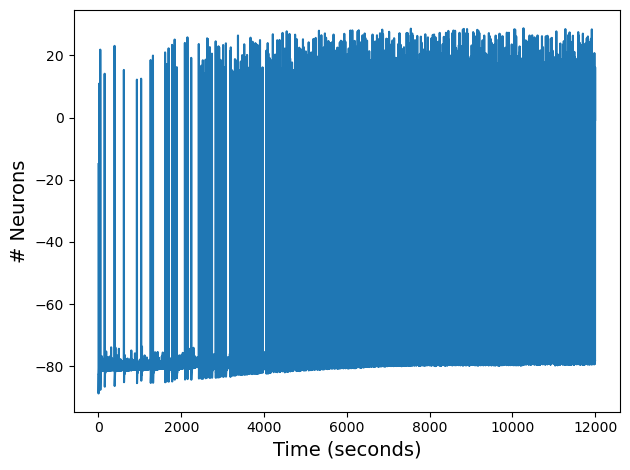

In [500]:
## plt.figure(figsize=(16,9))
#plt.title('Raster plot Mean Membrane potentials V_i')
plt.plot(np.nanmean(MG1.V[100:,:],axis=0))
plt.ylabel('# Neurons',fontsize='14')
plt.xlabel('Time (seconds)',fontsize='14')
#plt.yticks([0,2900],[0,3000])
#plt.xticks(np.arange(3300)[::300],np.round(np.linspace(0,6,11),1))
plt.tight_layout()
#plt.savefig('Population_raster.pdf')
plt.show()

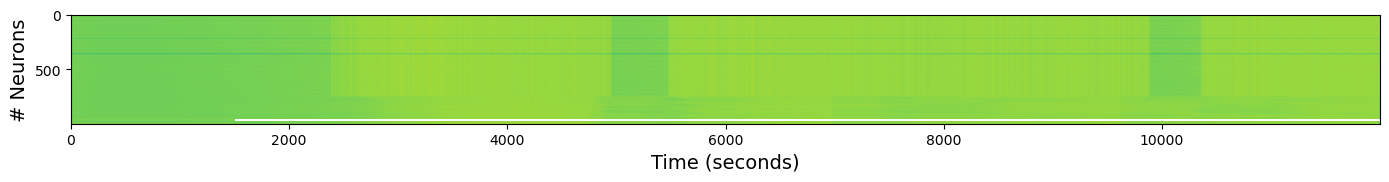

In [492]:
## plt.figure(figsize=(16,9))
#plt.title('Raster plot Mean Membrane potentials V_i')
plt.figure(figsize=(14,5))
plt.imshow(MG1.V)
plt.ylabel('# Neurons',fontsize='14')
plt.xlabel('Time (seconds)',fontsize='14')
#plt.yticks([0,2900],[0,3000])
#plt.xticks(np.arange(3300)[::300],np.round(np.linspace(0,6,11),1))
plt.tight_layout()
#plt.savefig('Population_raster.pdf')
plt.show()

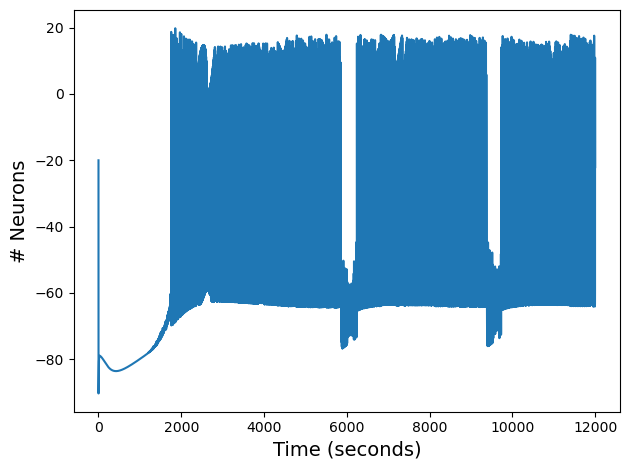

In [437]:
## plt.figure(figsize=(16,9))
#plt.title('Raster plot Mean Membrane potentials V_i')
plt.plot(np.mean(MG1.V[100:,:],axis=0))
plt.ylabel('# Neurons',fontsize='14')
plt.xlabel('Time (seconds)',fontsize='14')
#plt.yticks([0,2900],[0,3000])
#plt.xticks(np.arange(3300)[::300],np.round(np.linspace(0,6,11),1))
plt.tight_layout()
#plt.savefig('Population_raster.pdf')
plt.show()

In [375]:
MG1.V.shape

(1000, 6000)

In [302]:
DT = 0.01
duration_in_min = 1/3
TotTime = int(duration_in_min*60000)

In [303]:
TotTime

20000

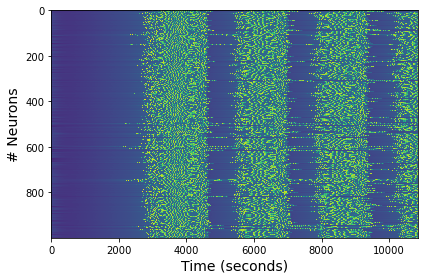

In [70]:
## plt.figure(figsize=(16,9))
#plt.title('Raster plot Mean Membrane potentials V_i')
plt.imshow(MG1.V,aspect='auto',interpolation='nearest',cmap='viridis')
plt.ylabel('# Neurons',fontsize='14')
plt.xlabel('Time (seconds)',fontsize='14')
#plt.yticks([0,2900],[0,3000])
#plt.xticks(np.arange(3300)[::300],np.round(np.linspace(0,6,11),1))
plt.tight_layout()
#plt.savefig('Population_raster.pdf')
plt.show()

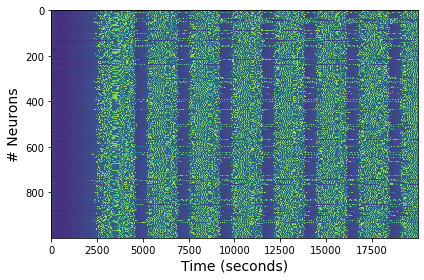

In [18]:
## plt.figure(figsize=(16,9))
#plt.title('Raster plot Mean Membrane potentials V_i')
plt.imshow(MG1.V,aspect='auto',interpolation='nearest',cmap='viridis')
plt.ylabel('# Neurons',fontsize='14')
plt.xlabel('Time (seconds)',fontsize='14')
#plt.yticks([0,2900],[0,3000])
#plt.xticks(np.arange(3300)[::300],np.round(np.linspace(0,6,11),1))
plt.tight_layout()
#plt.savefig('Population_raster.pdf')
plt.show()

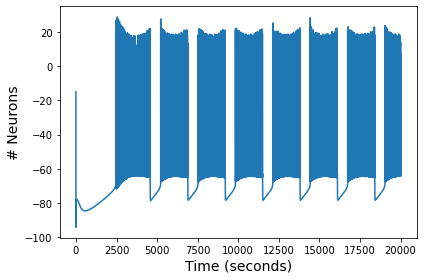

In [51]:
## plt.figure(figsize=(16,9))
#plt.title('Raster plot Mean Membrane potentials V_i')
plt.plot(MG1.V[352])
plt.ylabel('# Neurons',fontsize='14')
plt.xlabel('Time (seconds)',fontsize='14')
#plt.yticks([0,2900],[0,3000])
#plt.xticks(np.arange(3300)[::300],np.round(np.linspace(0,6,11),1))
plt.tight_layout()
#plt.savefig('Population_raster.pdf')
plt.show()

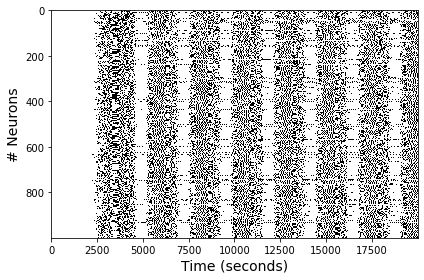

In [52]:
plt.figure(figsize=(6,4))
plt.imshow(np.where(MG1.V>-40,1,0)[:,:],aspect='auto',interpolation='none',cmap='gray_r')
plt.ylabel('# Neurons',fontsize='14')
plt.xlabel('Time (seconds)',fontsize='14')
plt.tight_layout()
#plt.savefig('Population_raster.pdf')
plt.show()

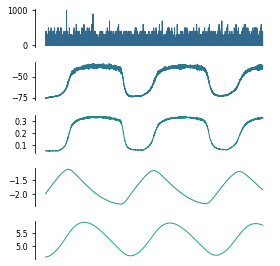

In [71]:
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

viridis = cm.get_cmap('viridis', 16)
print(viridis)

fig = plt.figure(figsize=(4,3.8))
ax1.set_title('Population')
ax1 = fig.add_subplot(511)
ax1.plot((FRG1.rate/hertz)[-6000:],c=viridis(5),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(512)
ax1.plot(np.mean(MG1.V[:,-6000:],axis=0),c=viridis(6),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(513)
ax1.plot(np.mean(MG1.n[:,-6000:],axis=0),c=viridis(7),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(514)
ax1.plot(np.mean(MG1.DK_i[:,-6000:],axis=0),c=viridis(8),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(515)
ax1.plot(np.mean(MG1.Kg[:,-6000:],axis=0),c=viridis(9),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

plt.tight_layout()
#plt.savefig('Figures/J2Regime.pdf')
plt.show()

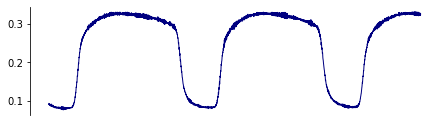

In [43]:
fig, ax = plt.subplots(figsize=(6.3,1.8))
ax.plot(np.mean(MG1.n[:,-6000:],axis=0),c='navy',linewidth=1)
#ax.hlines(0,0,105,color='k',linewidth=0.5)
#ax.set_ylim(2.998,3.002)
#ax.set_frame_on(0)
ax.spines["top"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticks([])
ax.tick_params(axis='both',labelsize=10)
#ax.set_yticks([])
plt.tight_layout()
#plt.savefig('K17.pdf')
plt.show()

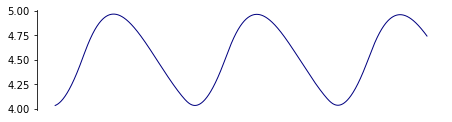

In [53]:
fig, ax = plt.subplots(figsize=(6.3,1.8))
ax.plot(np.mean(MG1.Kg[:,-6000:],axis=0),c='navy',linewidth=1)
#ax.hlines(0,0,105,color='k',linewidth=0.5)
#ax.set_ylim(2.998,3.002)
#ax.set_frame_on(0)
ax.spines["top"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticks([])
ax.tick_params(axis='both',labelsize=10)
#ax.set_yticks([])
plt.tight_layout()
#plt.savefig('K17.pdf')
plt.show()

In [36]:
MG1.Kg.shape

(1000, 20000)

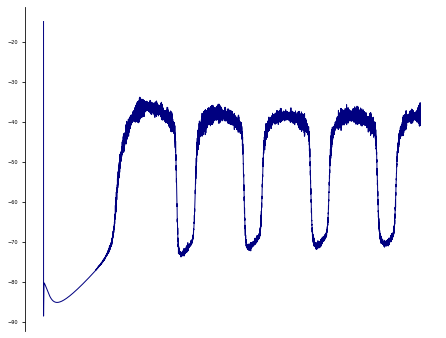

In [23]:
fig, ax = plt.subplots(figsize=(6.3,4.8))
ax.plot(np.mean(MG1.V[:,:13000],axis=0),c='navy',linewidth=1)
#ax.hlines(0,0,105,color='k',linewidth=0.5)
#ax.set_ylim(2.998,3.002)
#ax.set_frame_on(0)
ax.spines["top"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticks([])
ax.tick_params(axis='both',labelsize=5)
#ax.set_yticks([])
plt.tight_layout()
#plt.savefig('K17.pdf')
plt.show()

In [59]:
viridis = cm.get_cmap('viridis', 16)
print(viridis)

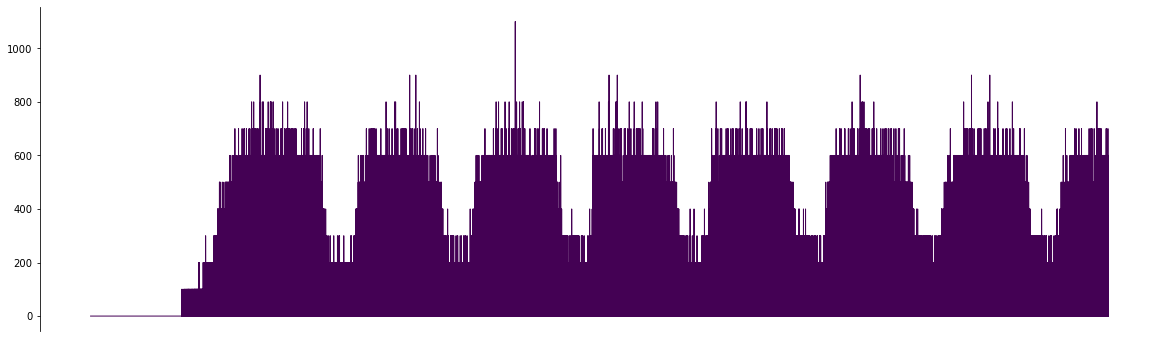

In [68]:
fig, ax = plt.subplots(figsize=(16.3,4.8))
ax.plot((FRG1.rate/hertz)[1000:],c=(0.267004, 0.004874, 0.329415, 1.0),linewidth=1)
#ax.hlines(0,0,105,color='k',linewidth=0.5)
#ax.set_ylim(2.998,3.002)
#ax.set_frame_on(0)
ax.spines["top"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticks([])
ax.tick_params(axis='both',labelsize=10)
#ax.set_yticks([])
plt.tight_layout()
#plt.savefig('K17.pdf')
plt.show()

In [27]:
FRG1.rate/hertz

array([100000.,      0.,      0., ...,    100.,    200.,    100.])

In [67]:
viridis(0)

(0.267004, 0.004874, 0.329415, 1.0)

In [276]:
from scipy import stats

In [ ]:
import pickle

def save_obj(obj, name ):
    with open('/Users/giovanni/Documents/GitHub/fufo/data/Interim/Abhirup/'+ name + '.pkl', 'wb') as f:
        pickle.dump(obj, f, pickle.HIGHEST_PROTOCOL)

In [231]:
Pop={'V':MG1.V}

In [232]:
save_obj(Pop,'Fig4_Population_75')

In [7]:
#%pylab nbaggpython
%matplotlib inline
#%matplotlib widget
import numpy as np
import glob
import os.path
import matplotlib.pyplot as plt 
from scipy import stats

In [1]:
path_abh='/Users/giovanni/Documents/GitHub/fufo/data/Interim/Abhirup/'

import pickle

def save_obj(obj, name ):
    with open(path_abh+ name + '.pkl', 'wb') as f:
        pickle.dump(obj, f, pickle.HIGHEST_PROTOCOL)

def load_obj(name ):
    with open(path_abh+ name + '.pkl', 'rb') as f:
        return pickle.load(f)

In [9]:
Pop=load_obj('Pop_kb7.5_J1_Delta1.5')

In [10]:
Pop['V'].shape

(3000, 20000)

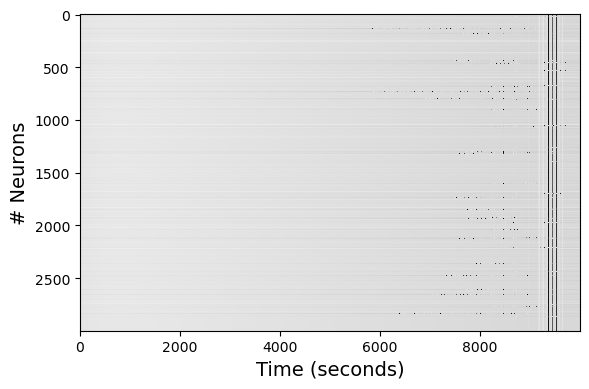

In [13]:
plt.figure(figsize=(6,4))
plt.imshow(Pop['V'][:,:10000],aspect='auto',interpolation='none',cmap='gray_r')
plt.ylabel('# Neurons',fontsize='14')
plt.xlabel('Time (seconds)',fontsize='14')
plt.tight_layout()
#plt.savefig('Population_raster.pdf')
plt.show()

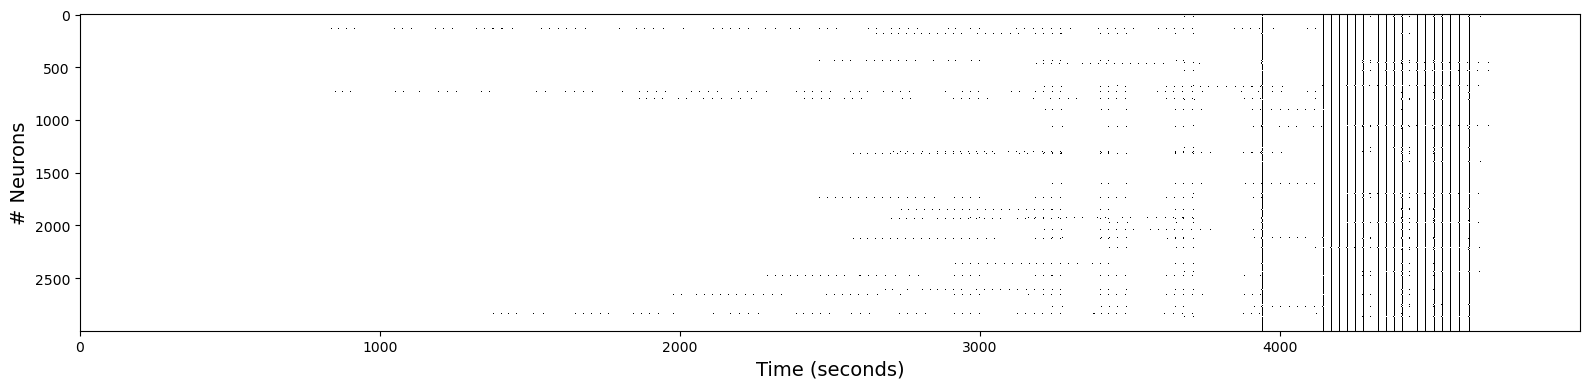

In [17]:
plt.figure(figsize=(16,4))
plt.imshow(np.where(Pop['V']>-40,1,0)[:,5000:10000],aspect='auto',interpolation='nearest',cmap='gray_r')
plt.ylabel('# Neurons',fontsize='14')
plt.xlabel('Time (seconds)',fontsize='14')
plt.tight_layout()
#plt.savefig('Population_raster.pdf')
plt.show()

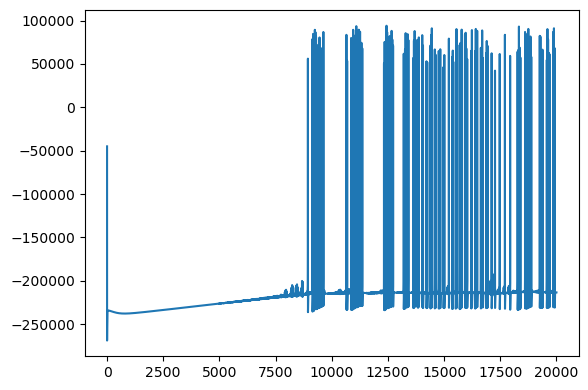

In [14]:
plt.figure(figsize=(6,4))
plt.plot(np.sum(Pop['V'],axis=0))
plt.tight_layout()
#plt.savefig('Population_raster.pdf')
plt.show()

In [115]:
Raster=Population[15.5]['V'][:,1000:11000][:,:]

In [113]:
#Raster=Pop['V'][:,6000:12000][:,::6]

In [215]:
tii=8350
tff=8550

jump=2700

tii=1100+jump
tff=1300+jump

x11=30
x22=145

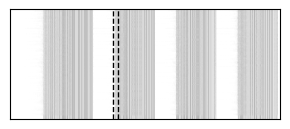

In [216]:
plt.figure(figsize=(3.,1.4))
plt.imshow(np.where(Raster>-0,1,0),aspect='auto',interpolation='gaussian',cmap='gist_gray_r')
plt.xticks([])
plt.yticks([])
plt.axvline(tii,linestyle='--',color='k',linewidth=1)
plt.axvline(tff,linestyle='--',color='k',linewidth=1)
plt.tight_layout()
plt.savefig('Fig3_Pop_rasterYYY.png',dpi=300)
plt.show()

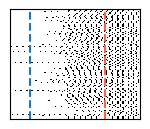

In [217]:
plt.figure(figsize=(1.6,1.4))
plt.imshow(np.where(Raster>-0,1,0)[:,tii:tff],aspect='auto',interpolation='none',cmap='gist_gray_r')
plt.xticks([])
plt.yticks([])
plt.axvline(x11,linestyle='--')
#plt.axvline(50,linestyle='--',color='k')
plt.axvline(x22,linestyle='--',color='tomato')
#plt.axvline(4550,linestyle='--',color='tomato')
plt.tight_layout()
plt.savefig('Fig3_Pop_rasterYYY.png',dpi=300)
plt.show()

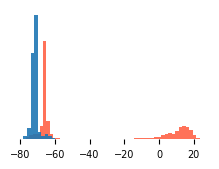

In [218]:
fig, ax = plt.subplots(figsize=(2.25,1.8))
#plt.title('Distribution at time red line')
ax.hist(Raster[:,tii:tff][:,x22],50,alpha=0.9,color='tomato')#D0A98F
ax.hist(Raster[:,tii:tff][:,x11],50,alpha=0.9)#D0A98F
#ax.hist(Raster[:,6100:6200][:,50],60,alpha=0.9,color='k')#D0A98F
ax.spines["top"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
#ax.set_xticks([-75,-70,-65,-60])
#ax.set_xlim(-77,-69)
ax.tick_params(axis='both',labelsize=7)
ax.set_yticks([])
plt.tight_layout()
plt.savefig(path+'Fig4_hist1YYY.pdf',dpi=300,transparent=True)
plt.show()

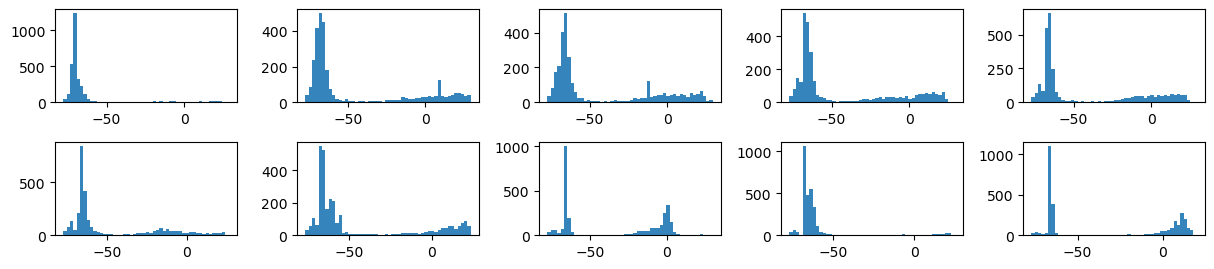

In [231]:
plt.figure(figsize=(12.25,2.8))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.hist(Raster[:,tii:tff][:,80+i*10],50,alpha=0.9)#D0A98F
plt.tight_layout()
#plt.savefig(path+'Fig4_hist1.pdf',dpi=300,transparent=True)
plt.show()

In [306]:
1100+1900

3000

In [ ]:
1000

In [316]:
Raster=Pop['V'][:,6000:12000][:,:]

In [317]:
tii=8350
tff=8550

jump=1900

tii=1100+jump
tff=1400+jump

x11=50
x22=170

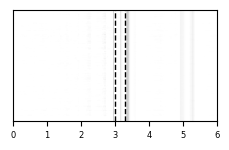

In [326]:
plt.figure(figsize=(2.4,1.6))
plt.imshow(np.where(Raster>-0,1,0),aspect='auto',interpolation='gaussian',cmap='gist_gray_r')
plt.xticks(np.linspace(0,6000,7), np.arange(7),fontsize=6)
plt.yticks([])
plt.axvline(tii,linestyle='--',color='k',linewidth=1)
plt.axvline(tff,linestyle='--',color='k',linewidth=1)
plt.tight_layout()
plt.savefig('Fig3_Pop_raster.png',dpi=300)
plt.show()

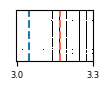

In [323]:
plt.figure(figsize=(1.2,1.))
plt.imshow(np.where(Raster>-0,1,0)[:,tii:tff],aspect='auto',interpolation='none',cmap='gist_gray_r')
plt.xticks(np.linspace(0,300,2), [3.0,3.3],fontsize=6)
plt.yticks([])
plt.axvline(x11,linestyle='--')
#plt.axvline(50,linestyle='--',color='k')
plt.axvline(x22,linestyle='--',color='tomato')
#plt.axvline(4550,linestyle='--',color='tomato')
plt.tight_layout()
plt.savefig('Fig3_Pop_raster_zoom.png',dpi=300)
plt.show()

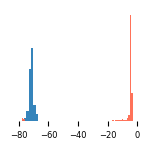

In [327]:
fig, ax = plt.subplots(figsize=(1.6,1.6))
#plt.title('Distribution at time red line')
ax.hist(Raster[:,tii:tff][:,x11],70,alpha=0.9)#D0A98F
ax.hist(Raster[:,tii:tff][:,x22],70,alpha=0.9,color='tomato')#D0A98F
#ax.hist(Raster[:,6100:6200][:,50],60,alpha=0.9,color='k')#D0A98F
ax.spines["top"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
#ax.set_xticks([-80,-60,-40,-20,0])
ax.set_xlim(-80,-0)
ax.tick_params(axis='both',labelsize=6)
ax.set_yticks([])
plt.tight_layout()
plt.savefig('Fig4_hist1.pdf',dpi=300,transparent=True)
plt.show()

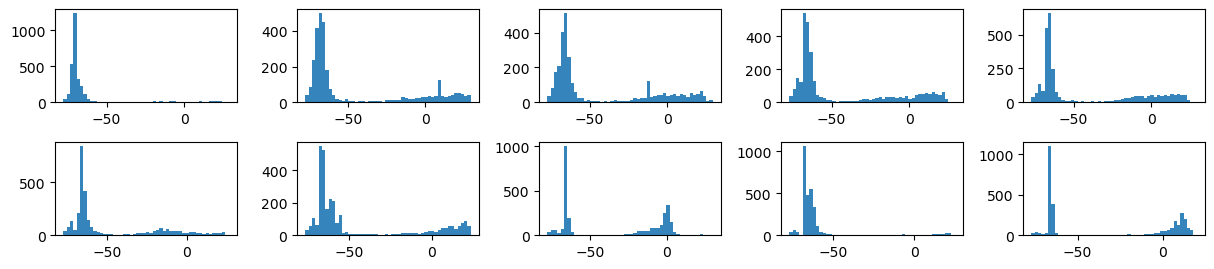

In [231]:
plt.figure(figsize=(12.25,2.8))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.hist(Raster[:,tii:tff][:,80+i*10],50,alpha=0.9)#D0A98F
plt.tight_layout()
#plt.savefig(path+'Fig4_hist1.pdf',dpi=300,transparent=True)
plt.show()

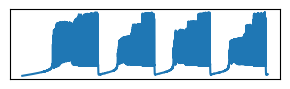

In [124]:
plt.figure(figsize=(3.,1.))
plt.plot(np.sum(Raster,axis=0))
plt.xticks([])
plt.yticks([])
plt.tight_layout()
#plt.savefig(path+'Fig3_Pop_raster.png',dpi=300)
plt.show()

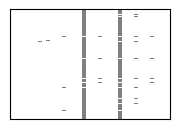

In [83]:
plt.figure(figsize=(1.9,1.4))
plt.imshow(np.where(Raster>-0,1,0)[:,510:550],aspect='auto',interpolation='none',cmap='bone_r',alpha=0.5)
plt.xticks([])
plt.yticks([])
#plt.axvline(450,linestyle='--')
#plt.axvline(550,linestyle='--')
plt.tight_layout()
#plt.savefig(path+'Fig3_Pop_raster.png',dpi=300)
plt.show()

In [381]:
#import pickle5 as pickle

with open('/Users/giovanni/Documents/GitHub/fufo/data/Interim/Abhirup/Carmela/Population_regime1.pkl', 'rb') as f:
    Population = pickle.load(f)

In [382]:
Population[15.5]['V'].shape

(3000, 20000)

In [383]:
Raster=Population[15.5]['V'][:,1000:11000][:,:]

In [384]:
#Raster=Pop['V'][:,6000:12000][:,::6]

In [385]:
tii=8350
tff=8550

jump=2700

tii=1100+jump
tff=1300+jump

x11=30
x22=145

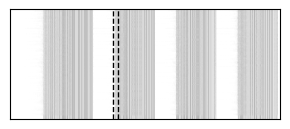

In [386]:
plt.figure(figsize=(3.,1.4))
plt.imshow(np.where(Raster>-0,1,0),aspect='auto',interpolation='gaussian',cmap='gist_gray_r')
plt.xticks([])
plt.yticks([])
plt.axvline(tii,linestyle='--',color='k',linewidth=1)
plt.axvline(tff,linestyle='--',color='k',linewidth=1)
plt.tight_layout()
plt.savefig('Fig3_Pop_rasterYYY.png',dpi=300)
plt.show()

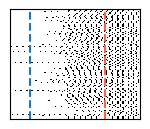

In [387]:
plt.figure(figsize=(1.6,1.4))
plt.imshow(np.where(Raster>-0,1,0)[:,tii:tff],aspect='auto',interpolation='none',cmap='gist_gray_r')
plt.xticks([])
plt.yticks([])
plt.axvline(x11,linestyle='--')
#plt.axvline(50,linestyle='--',color='k')
plt.axvline(x22,linestyle='--',color='tomato')
#plt.axvline(4550,linestyle='--',color='tomato')
plt.tight_layout()
plt.savefig('Fig3_Pop_rasterYYY.png',dpi=300)
plt.show()

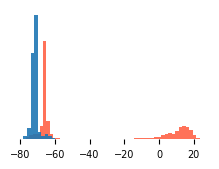

In [389]:
fig, ax = plt.subplots(figsize=(2.25,1.8))
#plt.title('Distribution at time red line')
ax.hist(Raster[:,tii:tff][:,x22],50,alpha=0.9,color='tomato')#D0A98F
ax.hist(Raster[:,tii:tff][:,x11],50,alpha=0.9)#D0A98F
#ax.hist(Raster[:,6100:6200][:,50],60,alpha=0.9,color='k')#D0A98F
ax.spines["top"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
#ax.set_xticks([-75,-70,-65,-60])
#ax.set_xlim(-77,-69)
ax.tick_params(axis='both',labelsize=7)
ax.set_yticks([])
plt.tight_layout()
plt.savefig('Fig4_hist1YYY.pdf',dpi=300,transparent=True)
plt.show()

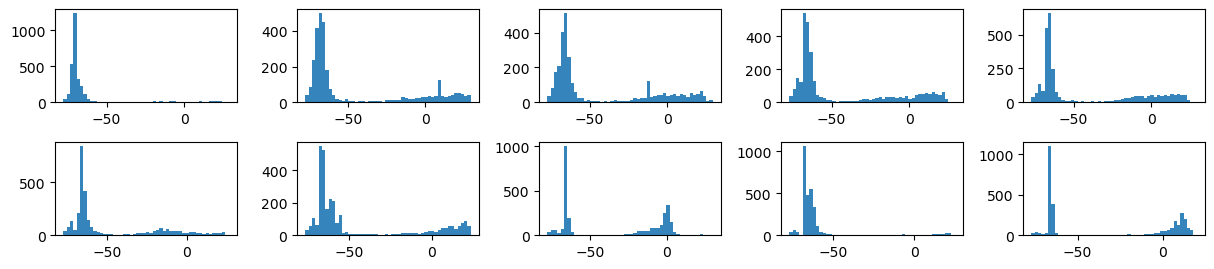

In [231]:
plt.figure(figsize=(12.25,2.8))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.hist(Raster[:,tii:tff][:,80+i*10],50,alpha=0.9)#D0A98F
plt.tight_layout()
#plt.savefig(path+'Fig4_hist1.pdf',dpi=300,transparent=True)
plt.show()

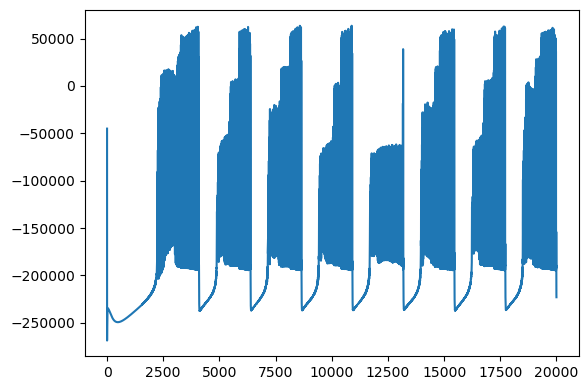

In [26]:
plt.figure(figsize=(6,4))
plt.plot(np.sum(Population[15.5]['V'],axis=0))
plt.tight_layout()
#plt.savefig('Population_raster.pdf')
plt.show()

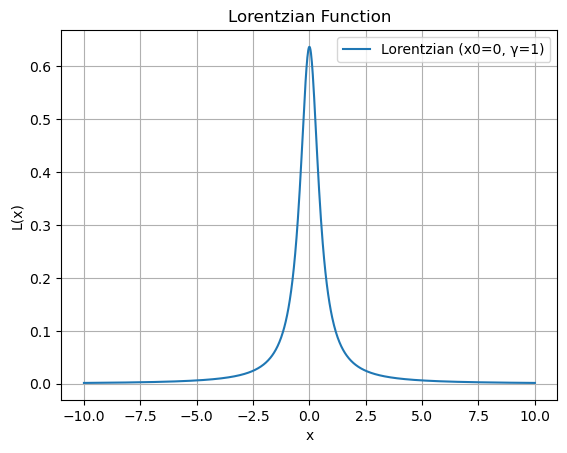

In [86]:
import numpy as np
import matplotlib.pyplot as plt

# Define the Lorentzian function
def lorentzian(x, x0, gamma):
    return (1/np.pi) * (gamma / 2) / ((x - x0)**2 + (gamma / 2)**2)

# Parameters
x0 = 0  # Peak position
gamma = 1  # Full width at half maximum (FWHM)

# Generate x values
x = np.linspace(-10, 10, 1000)

# Generate y values using the Lorentzian function
y = lorentzian(x, x0, gamma)

# Plot the Lorentzian function
plt.plot(x, y, label=f'Lorentzian (x0={x0}, γ={gamma})')
plt.xlabel('x')
plt.ylabel('L(x)')
plt.title('Lorentzian Function')
plt.legend()
plt.grid(True)
plt.show()


In [328]:
def h(n):
    return 1.1 - 1.0 / (1.0 + exp(-8 * (n - 0.4)))

In [330]:
Population[15.5]['V'].shape

(3000, 20000)

In [332]:
Population[15.5]

{'x': array([ 0.        ,  0.05329024,  0.07207009, ..., 38.68773437,
        40.50070791, 35.80208424]),
 'V': array([[-15.        , -89.49574185, -88.17747099, ..., -62.83330794,
         -62.92737372, -64.32952584],
        [-15.        , -89.52213722, -88.20817363, ..., -62.72663436,
         -63.13900336, -65.61095956],
        [-15.        , -89.58261073, -88.27850424, ..., -76.99147322,
         -77.39075516, -77.72149877],
        ...,
        [-15.        , -89.57434946, -88.26889732, ..., -76.95245153,
         -77.35470658, -77.68796094],
        [-15.        , -89.57434946, -88.26889732, ..., -76.95245153,
         -77.35470658, -77.68796094],
        [-15.        , -89.57434946, -88.26889732, ..., -76.95245153,
         -77.35470658, -77.68796094]]),
 'n': array([0.45      , 0.36187461, 0.28620623, ..., 0.08658469, 0.07817564,
        0.07138425]),
 'r': array([100000.,      0.,      0., ...,      0.,      0.,      0.]),
 'DK_i': array([-3.5       , -3.50234166, -3.503104 